### Histórico de Experimentos CNN - Raio-X Pneumonia

| Teste | Épocas | Acurácia Treino | Acurácia Validação | Acurácia Teste | Loss Validação | Taxa de Aprendizado (Final) | Observações (Top 5 Predições) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **01** Maioria do código base só diminuição de épocas | 20 | 90.31% | 79.49% | 79.49% | 0.6572 | 0.0085 | Errou 4/5 (falso positivo para Pneumonia). Modelo inclinado a prever a classe majoritária. |
| **02** Aumento de épocas | 100 | 97.32% | 74.68% | 74.68% | 1.1724 | 0.0044 | Piora nos resultados de teste e validação. Loss de validação quase dobrou — overfitting claro. Errou 4/5. |
| **03** Diminuição de épocas e adição de sample_weights | 15 | 78.21% | 63.94% | 63.94% | 0.8766 | 0.0088 | sample_weight ainda não corrigiu o viés: errou 5/5 no top-5, prevendo PNEUMONIA para todos os casos NORMAL com alta confiança. Queda expressiva indica colapso na última época. |
| **04** Adição data augmentation e L2 | 15 | 58.57% | 37.66% | 37.66% | 1.9341 | 0.0088 | **Underfitting severo** após adição de Augmentation + L2. Modelo não teve tempo de aprender e previu "NORMAL" para todas as imagens (probs travadas em ~0.48). Acertou 5/5 apenas por coincidência. |
| **05** Compilação completa (Métricas + Early Stop) | 15 | 48.26% | 55.61% | 55.61% | 1.9264 | 0.0088 | AUC promissor (0.77), indicando que o modelo está aprendendo a separar as classes. Porém, CM revela viés invertido (muitos Falsos Negativos: 271) devido ao sample_weight. Necessita de mais épocas para convergir. |
| **06** Teste aumentando as épocas | 100 -> 29 (Stop) | 58.99% | 77.08% | 77.08% | 1.7601 | 0.0082 | **Modelo equilibrado**. Early Stopping interrompeu na época 29 e restaurou a 24. Acurácia sólida, AUC excelente de 0.87. As probabilidades distanciaram-se de 0.5. |
| **07** Novo teste (50 Épocas + URLs externas) | 50 -> 22 (Stop) | 61.39% | 73.24% | 73.24% | 1.8507 | 0.0088 | **Alta Sensibilidade Médica**. Parou na época 22 (restaurou a 17). O modelo priorizou minimizar Falsos Negativos (caíram para apenas 11), gerando mais Falsos Positivos (156). Comportamento excelente para triagem. AUC estável em 0.86. |
| **08** Repetição do T07 | 50 -> 30 (Stop) | 62.26% | 70.99% | 70.99% | 1.7172 | 0.0082 | **Confirmação do padrão de Triagem**. Parou na época 30 (restaurou a 25). AUC excelente (0.869). O modelo mantém a segurança de não deixar doentes passarem (apenas 9 FN) à custa de diagnosticar saudáveis com pneumonia (172 FP). |

## Bibliotecas

In [1]:
# Importação das bibliotecas necessárias
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, MaxPooling2D, Dropout, Dense, Input, concatenate, GlobalAveragePooling2D, AveragePooling2D, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.callbacks import LearningRateScheduler
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import requests
from PIL import Image
from io import BytesIO
import os
import glob
import time

2026-05-05 18:58:33.464858: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778007513.871602      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778007513.990274      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778007514.977763      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778007514.977807      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778007514.977810      22 computation_placer.cc:177] computation placer alr

In [2]:
# Verifica a quantidade de GPUs disponíveis
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


## Database

### 🔧 MODIFICAÇÃO 1/8 — Troca de Dataset

**Original:** `cifar10.load_data()` — dataset de 10 classes (avião, carro, pássaro...)

**Novo:** Chest X-Ray Pneumonia — dataset de **2 classes**: `NORMAL` (0) e `PNEUMONIA` (1)

**Por que este dataset?**
- Imagens altamente padronizadas (todas são radiografias frontais de tórax)
- Mesmo protocolo de captura → baixa variabilidade visual
- ~5.856 imagens com split train/test/val já pronto
- Dataset de referência acadêmica (Kermany et al., 2018)

**Kaggle slug:** `paultimothymooney/chest-xray-pneumonia`

In [3]:
def find_dataset_root(base='/kaggle/input/datasets/paultimothymooney'):
    for root, dirs, files in os.walk(base):
        if 'train' in dirs and 'test' in dirs:
            print(f"Dataset encontrado em: {root}")
            return root
    raise FileNotFoundError(f"Pastas 'train'/'test' não encontradas dentro de {base}")

def load_chestxray_data(img_rows, img_cols,
                        base_path='/kaggle/input/datasets/paultimothymooney'):
    real_path = find_dataset_root(base_path)

    def load_split(split_name):
        images, labels = [], []
        split_path = os.path.join(real_path, split_name)

        for label_idx, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
            class_path = os.path.join(split_path, class_name)
            all_files = os.listdir(class_path)
            filepaths = [
                os.path.join(class_path, f)
                for f in all_files
                if f.lower().endswith(('.jpeg', '.jpg', '.png'))
            ]
            print(f'  [{split_name}] {class_name}: {len(filepaths)} imagens')

            for fp in filepaths:
                img = cv2.imread(fp)
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_cols, img_rows))
                images.append(img)
                labels.append(label_idx)

        X = np.array(images, dtype='float32') / 255.0
        y = np.array(labels, dtype='float32').reshape(-1, 1)
        return X, y

    print('Carregando dados...')
    X_train, y_train = load_split('train')
    X_test,  y_test  = load_split('test')

    print(f'\nX_train: {X_train.shape} | y_train: {y_train.shape}')
    print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_chestxray_data(32, 32)
class_names = ['NORMAL', 'PNEUMONIA']

Dataset encontrado em: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Carregando dados...
  [train] NORMAL: 1341 imagens
  [train] PNEUMONIA: 3875 imagens
  [test] NORMAL: 234 imagens
  [test] PNEUMONIA: 390 imagens

X_train: (5216, 32, 32, 3) | y_train: (5216, 1)
X_test:  (624, 32, 32, 3)  | y_test:  (624, 1)


Distribuição no treino: NORMAL=1341 | PNEUMONIA=3875 | Total=5216
Proporção: 25.7% NORMAL | 74.3% PNEUMONIA


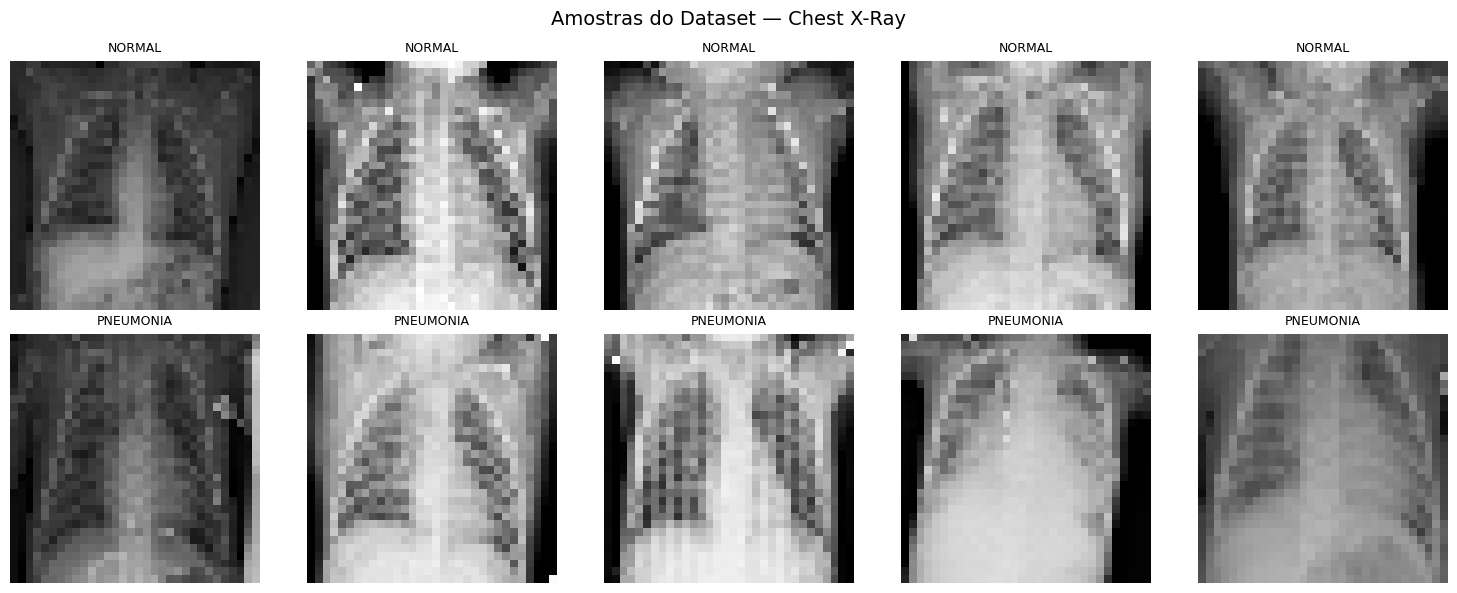

In [4]:
# Distribuição das classes — versão segura
n_normal    = int(np.sum(y_train == 0))
n_pneumonia = int(np.sum(y_train == 1))
total       = n_normal + n_pneumonia

print(f'Distribuição no treino: NORMAL={n_normal} | PNEUMONIA={n_pneumonia} | Total={total}')

if total > 0:
    print(f'Proporção: {n_normal/total:.1%} NORMAL | {n_pneumonia/total:.1%} PNEUMONIA')

    # Visualização de amostras
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Amostras do Dataset — Chest X-Ray', fontsize=14)

    for class_idx, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
        indices = np.where(y_train.flatten() == class_idx)[0][:5]
        for col, idx in enumerate(indices):
            axes[class_idx, col].imshow(X_train[idx])
            axes[class_idx, col].set_title(class_name, fontsize=9)
            axes[class_idx, col].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma imagem carregada. Verifique o caminho do dataset acima.")

## Inicializadores (idênticos ao código base)

In [5]:
# ✅ IDÊNTICO AO CÓDIGO BASE
kernel_init = tf.keras.initializers.GlorotUniform()
bias_init   = tf.keras.initializers.Constant(value=0.2)

## Inception Module (idêntico ao código base)

In [6]:
# ✅ IDÊNTICO AO CÓDIGO BASE — função inception_module sem alterações
def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3,
                     filters_5x5_reduce, filters_5x5, filters_pool_proj, name=None):
    conv_1x1 = Conv2D(filters_1x1, (1, 1), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(x)

    conv_3x3 = Conv2D(filters_3x3_reduce, (1, 1), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(x)
    conv_3x3 = Conv2D(filters_3x3, (3, 3), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(conv_3x3)

    conv_5x5 = Conv2D(filters_5x5_reduce, (1, 1), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(x)
    conv_5x5 = Conv2D(filters_5x5, (5, 5), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(conv_5x5)

    pool_proj = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool_proj = Conv2D(filters_pool_proj, (1, 1), padding='same', activation='relu',
                       kernel_initializer=kernel_init, bias_initializer=bias_init)(pool_proj)

    output = concatenate([conv_1x1, conv_3x3, conv_5x5, pool_proj], axis=3, name=name)
    return output

## Definição do Modelo de Inception

### 🔧 MODIFICAÇÕES 2 e 3/8 — kernel_size e stride

Aplicadas **somente na primeira camada convolucional** (`conv_1`), conforme escopo definido.

```
ANTES:  Conv2D(64, (7, 7), strides=(2, 2), ...)
DEPOIS: Conv2D(64, (3, 3), strides=(1, 1), ...)
```

**Impacto no shape intermediário:**
| Camada | Shape ANTES | Shape DEPOIS |
|---|---|---|
| Input | (32, 32, 3) | (32, 32, 3) |
| Conv 1 (kernel+stride) | (16, 16, 64) | **(32, 32, 64)** |
| MaxPool 1 | (8, 8, 64) | (16, 16, 64) |
| ... restante da rede ... | propaga redução | propaga redução |

 BLOCO 1 — ARQUITETURA COM DATA AUGMENTATION E L2

 As camadas de augmentation ficam DENTRO do modelo:
 → rodam apenas no treino (training=True), são ignoradas na inferência.
 → Flip horizontal é seguro para Raio-X frontal.
 → Rotação leve (±5%) e zoom (±5%) simulam variações de posicionamento do paciente.

In [7]:
# --- Augmentation pipeline (primeiras camadas do modelo) ---
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(factor=0.05),   # ±5% de rotação (~18°)
    tf.keras.layers.RandomZoom(height_factor=0.05), # ±5% de zoom
], name='data_augmentation')

# --- Entrada ---
input_layer = Input(shape=(32, 32, 3))

# Augmentation aplicada ao input (só ativa durante model.fit)
x = augmentation(input_layer)

# --- Stem (mantém kernel 3x3 e stride 1x1 conforme modificações anteriores) ---
x = Conv2D(64, (3, 3), padding='same', strides=(1, 1), activation='relu')(x)
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
x = Conv2D(64, (1, 1), padding='same', activation='relu')(x)
x = Conv2D(192, (3, 3), padding='same', activation='relu')(x)
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

# --- Inception Modules (função inception_module inalterada do código base) ---
x = inception_module(x, 64,  96,  128, 16, 32, 32, name='inception_3a')
x = inception_module(x, 128, 128, 192, 32, 96, 64, name='inception_3b')
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
x = inception_module(x, 192,  96, 208, 16, 48, 64, name='inception_4a')

# --- Saída Auxiliar (aux1) com L2 na Dense ---
# 🔧 CORREÇÃO AQUI: AveragePooling2D ajustado para mapas 4x4 (padrão 32x32)
aux1 = AveragePooling2D((3, 3), strides=(2, 2), padding='same')(x)
aux1 = Conv2D(128, (1, 1), padding='same', activation='relu')(aux1)
aux1 = Flatten()(aux1)
aux1 = Dense(1024, activation='relu',
             kernel_regularizer=tf.keras.regularizers.l2(0.001))(aux1)  # ← L2
aux1 = Dropout(0.7)(aux1)
aux1_output = Dense(1, activation='sigmoid',
                    kernel_regularizer=tf.keras.regularizers.l2(0.001),  # ← L2
                    name='auxilliary_output_1')(aux1)

x = inception_module(x, 160, 112, 224, 24, 64, 64, name='inception_4b')
x = inception_module(x, 128, 128, 256, 24, 64, 64, name='inception_4c')
x = inception_module(x, 112, 144, 288, 32, 64, 64, name='inception_4d')
x = inception_module(x, 256, 160, 320, 32, 128, 128, name='inception_4e')
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
x = inception_module(x, 256, 160, 320, 32, 128, 128, name='inception_5a')
x = inception_module(x, 384, 192, 384, 48, 128, 128, name='inception_5b')

# --- Saída Principal com L2 na Dense ---
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)       # ← L2
main_output = Dense(1, activation='sigmoid',
                    kernel_regularizer=tf.keras.regularizers.l2(0.001), # ← L2
                    name='output')(x)

model = Model(inputs=input_layer, outputs=[main_output, aux1_output])
model.summary()

I0000 00:00:1778007663.412376      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778007663.418009      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,792 │ data_augmentatio… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │    110,784 │ conv2d_1[0][0]    │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 192) │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 96)  │     18,528 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 16)  │      3,088 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 192) │          0 │ max_pooling2d_1[… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 64)  │     12,352 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 128) │    110,720 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 32)  │     12,832 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 32)  │      6,176 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a        │ (None, 8, 8, 256) │          0 │ conv2d_3[0][0],   │
│ (Concatenate)       │                   │            │ conv2d_5[0][0],   │
│                     │                   │            │ conv2d_7[0][0],   │
│                     │                   │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 8, 8, 128) │     32,896 │ inception_3a[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 8, 8, 32)  │      8,224 │ inception_3a[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 256) │          0 │ inception_3a[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 128) │     32,896 │ inception_3a[0][

 Total params: 6,820,530 (26.02 MB)

 Trainable params: 6,820,530 (26.02 MB)

 Non-trainable params: 0 (0.00 B)

## Parâmetros de Treinamento

In [8]:
epochs = 50           # ✅ IDÊNTICO AO CÓDIGO BASE
initial_lrate = 0.01   # ✅ IDÊNTICO AO CÓDIGO BASE

## Função de Decaimento da Taxa de Aprendizado (idêntica ao código base)

In [9]:
# ✅ IDÊNTICO AO CÓDIGO BASE
def decay(epoch):
    drop = 0.96
    epochs_drop = 5
    lrate = initial_lrate * math.pow(drop, math.floor((1+epoch)/epochs_drop))
    return lrate

## Compilação do Modelo

### 🔧 MODIFICAÇÃO 6/8 — Loss: categorical_crossentropy → binary_crossentropy

```
ANTES:  loss=['categorical_crossentropy', 'categorical_crossentropy']
DEPOIS: loss=['binary_crossentropy',      'binary_crossentropy']
```

Tudo mais (`loss_weights`, `optimizer`, `metrics`) permanece idêntico ao código base.



BLOCO 2 — COMPILAÇÃO E CALLBACKS
 
 --- Compilação com métricas expandidas ---
 AUC-ROC na saída principal: mede separabilidade independente do threshold.
 Recall na saída principal: crítico para diagnóstico médico (minimizar falsos negativos).
 A saída auxiliar mantém só accuracy (peso 0.3, papel de regularizador de gradiente).

In [10]:
# --- Otimizador (inalterado do código base) ---
optim = SGD(learning_rate=initial_lrate, momentum=0.9, nesterov=False)

model.compile(
    loss=['binary_crossentropy', 'binary_crossentropy'],
    loss_weights=[1, 0.3],
    optimizer=optim,
    metrics=[
        [
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ],
        ['accuracy']
    ]
)

# --- Callbacks ---
lr_sc = LearningRateScheduler(decay, verbose=1)  # inalterado do código base

# Early Stopping: para o treino se val_loss não melhorar em 5 épocas consecutivas
# e restaura os pesos da melhor época automaticamente.
# → Teria evitado o colapso da época 15 no Teste 03.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# --- Pesos de amostra (sample_weight, sem sklearn) ---
total           = len(y_train.flatten())
n_classes       = 2
count_normal    = np.sum(y_train.flatten() == 0)
count_pneumonia = np.sum(y_train.flatten() == 1)
weight_normal    = total / (n_classes * count_normal)
weight_pneumonia = total / (n_classes * count_pneumonia)
weight_normal = weight_normal * 0.65
sample_weights   = np.where(y_train.flatten() == 0, weight_normal, weight_pneumonia)
print(f"Pesos → NORMAL: {weight_normal:.3f} | PNEUMONIA: {weight_pneumonia:.3f}")

# --- Treinamento ---
with tf.device('/gpu:0'):
    history = model.fit(
        X_train,
        [y_train, y_train],
        validation_data=(X_test, [y_test, y_test]),
        epochs=epochs,
        batch_size=512,
        callbacks=[lr_sc, early_stop],          # ← early_stop adicionado
        sample_weight=[sample_weights, sample_weights]
    )

Pesos → NORMAL: 1.264 | PNEUMONIA: 0.673

Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/50


I0000 00:00:1778007676.122605      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 611ms/step - auxilliary_output_1_accuracy: 0.6129 - auxilliary_output_1_loss: 0.5854 - loss: 1.8415 - output_accuracy: 0.6664 - output_auc: 0.5110 - output_loss: 0.5713 - output_precision: 0.7491 - output_recall: 0.8296 - val_auxilliary_output_1_accuracy: 0.6250 - val_auxilliary_output_1_loss: 0.5899 - val_loss: 1.9527 - val_output_accuracy: 0.6250 - val_output_auc: 0.5000 - val_output_loss: 0.5763 - val_output_precision: 0.6250 - val_output_recall: 1.0000 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.01.
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - auxilliary_output_1_accuracy: 0.6492 - auxilliary_output_1_loss: 0.5763 - loss: 1.8352 - output_accuracy: 0.6939 - output_auc: 0.4908 - output_loss: 0.5696 - output_precision: 0.7369 - output_recall: 0.9109 - val_auxilliary_output_1_accuracy: 0.6250 - val_auxilliary_output_1_loss: 0.5860 - val_loss: 1.9611 - val_output_accuracy: 0.6250 - val_output_auc: 0.5000 - va

## Visualização do Treinamento

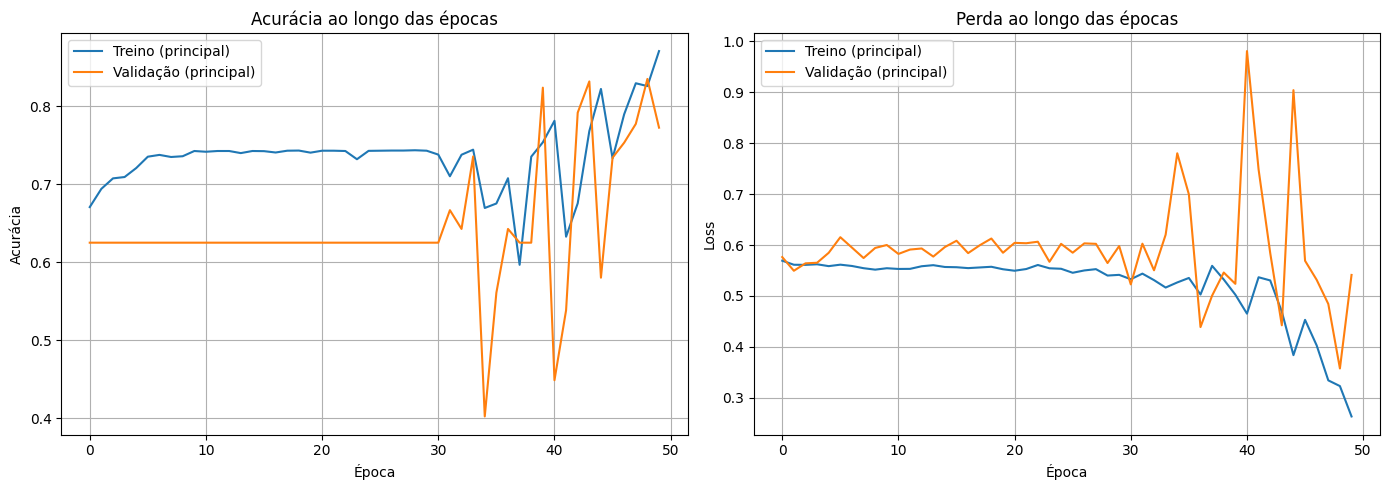

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia
axes[0].plot(history.history['output_accuracy'],     label='Treino (principal)')
axes[0].plot(history.history['val_output_accuracy'], label='Validação (principal)')
axes[0].set_title('Acurácia ao longo das épocas')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True)

# Perda
axes[1].plot(history.history['output_loss'],     label='Treino (principal)')
axes[1].plot(history.history['val_output_loss'], label='Validação (principal)')
axes[1].set_title('Perda ao longo das épocas')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Avaliação e Predições

### 🔧 MODIFICAÇÃO 7e8/8 — Interpretação da saída: argmax → threshold (sigmoid)

Com sigmoid, a saída é um único valor em [0, 1]:
- `pred < 0.5` → NORMAL
- `pred >= 0.5` → PNEUMONIA


 BLOCO 3 — MATRIZ DE CONFUSÃO

 Mostra exatamente quantos NORMAL → PNEUMONIA (falsos positivos)
 e quantos PNEUMONIA → NORMAL (falsos negativos) estão ocorrendo.

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step

=== Primeiros 5 exemplos do conjunto de teste ===
  [0] Predito: PNEUMONIA  | Real: NORMAL     | Prob: 0.7730 ❌
  [1] Predito: NORMAL     | Real: NORMAL     | Prob: 0.1539 ✅
  [2] Predito: NORMAL     | Real: NORMAL     | Prob: 0.1031 ✅
  [3] Predito: NORMAL     | Real: NORMAL     | Prob: 0.3371 ✅
  [4] Predito: NORMAL     | Real: NORMAL     | Prob: 0.1323 ✅

Acurácia no conjunto de teste: 0.8349 (83.49%)


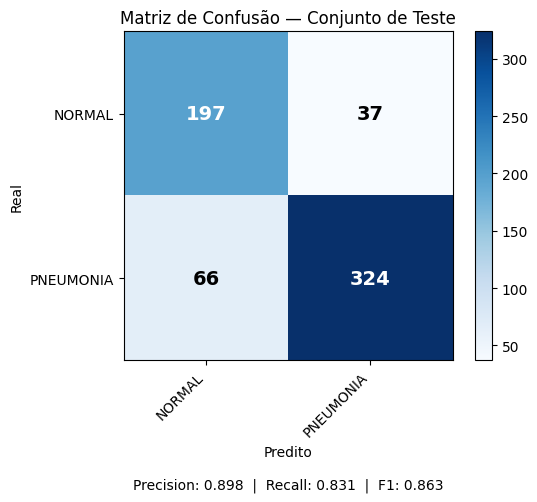


  TN (NORMAL→NORMAL):       197
  FP (NORMAL→PNEUMONIA):    37  ← viés do modelo
  FN (PNEUMONIA→NORMAL):    66
  TP (PNEUMONIA→PNEUMONIA): 324


In [12]:
# --- Predições ---
predictions = model.predict(X_test)
main_predictions, aux1_predictions = predictions

predicted_classes = (main_predictions >= 0.5).astype(int).flatten()
true_classes      = y_test.flatten().astype(int)

# --- Top-5 e Acurácia (bloco original mantido) ---
print('\n=== Primeiros 5 exemplos do conjunto de teste ===')
for i in range(5):
    prob   = main_predictions[i][0]
    pred   = class_names[predicted_classes[i]]
    true   = class_names[true_classes[i]]
    status = '✅' if predicted_classes[i] == true_classes[i] else '❌'
    print(f'  [{i}] Predito: {pred:10s} | Real: {true:10s} | Prob: {prob:.4f} {status}')

acc = np.mean(predicted_classes == true_classes)
print(f'\nAcurácia no conjunto de teste: {acc:.4f} ({acc*100:.2f}%)')

# --- Matriz de Confusão (puro NumPy + Matplotlib, sem sklearn) ---
def plot_confusion_matrix(y_true, y_pred, class_names):
    n = len(class_names)
    cm = np.zeros((n, n), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[true][pred] += 1

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(n),
        yticks=np.arange(n),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel='Predito',
        ylabel='Real',
        title='Matriz de Confusão — Conjunto de Teste'
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    thresh = cm.max() / 2
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{cm[i, j]}',
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black',
                    fontsize=14, fontweight='bold')

    # Anotações de métricas-chave
    tn, fp = cm[0][0], cm[0][1]   # NORMAL real → predito NORMAL / PNEUMONIA
    fn, tp = cm[1][0], cm[1][1]   # PNEUMONIA real → predito NORMAL / PNEUMONIA
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    ax.set_xlabel(
        f'Predito\n\nPrecision: {precision:.3f}  |  Recall: {recall:.3f}  |  F1: {f1:.3f}',
        fontsize=10
    )

    plt.tight_layout()
    plt.show()
    print(f'\n  TN (NORMAL→NORMAL):       {tn}')
    print(f'  FP (NORMAL→PNEUMONIA):    {fp}  ← viés do modelo')
    print(f'  FN (PNEUMONIA→NORMAL):    {fn}')
    print(f'  TP (PNEUMONIA→PNEUMONIA): {tp}')

plot_confusion_matrix(true_classes, predicted_classes, class_names)

## Salvamento do Modelo

In [13]:
# Salva o modelo treinado
model.save('inception_v1_binary_chestxray.h5')
print('Modelo salvo: inception_v1_binary_chestxray.h5')

Modelo salvo: inception_v1_binary_chestxray.h5


## Predição em Imagens Individuais (via URL)

In [14]:
# URLs de exemplo
image_urls = [
    'https://prod-images-static.radiopaedia.org/images/220869/76052f7902246ff862f52f5d3cd9cd_big_gallery.jpg',
    'https://prod-images-static.radiopaedia.org/images/554213/27e6e725de1f349479fd214944aaf0d32523ec38f111107b6f347a3530e4b4ff_big_gallery.jpeg',
    'https://en.wikipedia.org/wiki/Special:FilePath/Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg',
    'https://en.wikipedia.org/wiki/Special:FilePath/Pneumonia_x-ray.jpg',
    'https://en.wikipedia.org/wiki/Special:FilePath/Lobar_pneumonia,_acute_(3785988179).jpg',
    'https://en.wikipedia.org/wiki/Special:FilePath/Rx_t%C3%B3rax_normal_F.JPG',
    'https://en.wikipedia.org/wiki/Special:FilePath/X-ray_of_bronchopneumonia.png'
]

def load_and_preprocess_image(url):
    try:
        # 🔧 Header mais robusto simulando um Google Chrome no Windows
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
        }
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        img = img.resize((32, 32))
        img_array = image.img_to_array(img)
        
        if img_array.shape[2] == 1:
            img_array = np.repeat(img_array, 3, axis=2)
        elif img_array.shape[2] == 4:
            img_array = img_array[:, :, :3]
        
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        return img_array
    except Exception as e:
        print(f'Erro ao carregar imagem de {url}: {e}')
        return None

for url in image_urls:
    img_array = load_and_preprocess_image(url)
    if img_array is not None:
        predictions = model.predict(img_array, verbose=0)
        main_pred = predictions[0]
        prob = main_pred[0][0]
        predicted_class = class_names[int(prob >= 0.5)]
        print(f'URL: ...{url[-40:]}')
        print(f'  Predito: {predicted_class:10s} | Probabilidade de PNEUMONIA: {prob:.4f}')
    else:
        print(f'Pulando imagem de {url} devido a erro de carregamento.')
    
    # 🔧 Delay de 2 segundos para evitar o Erro 429 da Wikipedia
    time.sleep(2)

URL: ...7902246ff862f52f5d3cd9cd_big_gallery.jpg
  Predito: NORMAL     | Probabilidade de PNEUMONIA: 0.0917
URL: ...111107b6f347a3530e4b4ff_big_gallery.jpeg
  Predito: PNEUMONIA  | Probabilidade de PNEUMONIA: 0.9732
URL: ...terior_(PA)_chest_radiograph_(X-ray).jpg
  Predito: NORMAL     | Probabilidade de PNEUMONIA: 0.4249
URL: ...iki/Special:FilePath/Pneumonia_x-ray.jpg
  Predito: NORMAL     | Probabilidade de PNEUMONIA: 0.0881
URL: .../Lobar_pneumonia,_acute_(3785988179).jpg
  Predito: PNEUMONIA  | Probabilidade de PNEUMONIA: 0.9831
URL: ...cial:FilePath/Rx_t%C3%B3rax_normal_F.JPG
  Predito: NORMAL     | Probabilidade de PNEUMONIA: 0.0975
Erro ao carregar imagem de https://en.wikipedia.org/wiki/Special:FilePath/X-ray_of_bronchopneumonia.png: 429 Client Error: Too many requests (f061ab2) for url: https://upload.wikimedia.org/wikipedia/commons/6/6e/X-ray_of_bronchopneumonia.png
Pulando imagem de https://en.wikipedia.org/wiki/Special:FilePath/X-ray_of_bronchopneumonia.png devido a erro d